# Assignment 2

## Task 0: Course Project Dataset Exploration

### a) Dataset choice

I plan to use the **Netflix Movies and TV Shows** dataset from Kaggle.

**Source:**  
https://www.kaggle.com/datasets/shivamb/netflix-shows

### b) Dataset description

The dataset contains information about movies and TV shows available on Netflix.
Each row represents one title on the platform.

**Main variables include:**
- type (Movie or TV Show)
- title
- director
- cast
- country
- release_year
- rating
- duration
- listed_in (genres)

The dataset contains approximately 8,800 rows.
In the project, I plan to analyze content trends over time, such as genre distribution,
movie vs TV show proportions, and regional availability.

In [17]:
df = pd.read_csv("netflix_titles.csv.zip")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [19]:
df.shape

(8807, 12)

In [21]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


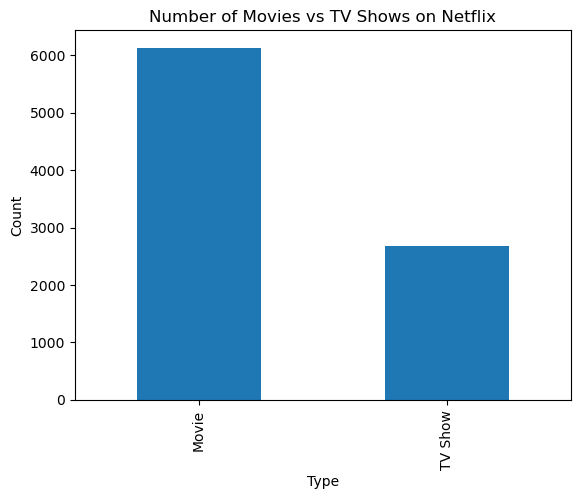

In [23]:
df["type"].value_counts().plot(kind="bar")
plt.title("Number of Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

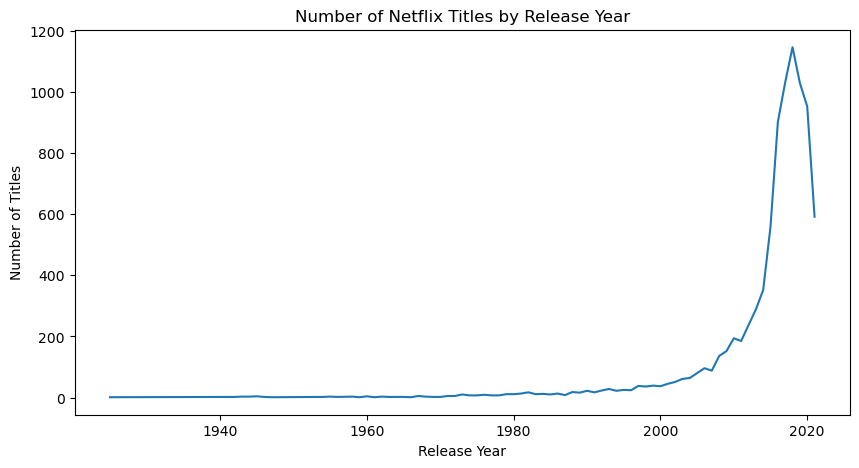

In [25]:
df["release_year"].value_counts().sort_index().plot(figsize=(10, 5))
plt.title("Number of Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

### Exploratory Data Analysis Summary

The exploratory analysis shows that Netflix offers more movies than TV shows.
The number of titles added increases significantly after 2015, indicating rapid
growth in content production in recent years. This dataset provides a good basis
for analyzing content trends over time.

## Task 1: API key and .env file

In [39]:
from dotenv import load_dotenv
import os

load_dotenv("C:/elmer-repo/assignments/assignment2/.env")

api_key = os.getenv("MARKETSTACK_API_KEY")
print(api_key[:5] + "...")

95720...


## Task 2: FAANG stock performance in March 2026 (Marketstack API)

In [42]:
import requests
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv("C:/elmer-repo/assignments/assignment2/.env")
API_KEY = os.getenv("MARKETSTACK_API_KEY")

In [46]:
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]

start_date = "2026-03-01"
end_date = "2026-03-31"


In [48]:
all_data = []

for ticker in tickers:
    url = "http://api.marketstack.com/v1/eod"
    
    params = {
        "access_key": API_KEY,
        "symbols": ticker,
        "date_from": start_date,
        "date_to": end_date
    }
    
    response = requests.get(url, params=params)
    data = response.json()["data"]
    
    all_data.extend(data)

In [50]:
df = pd.DataFrame(all_data)
df.head()

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,549.98,573.69,546.77,572.13,32809500.0,573.6900,546.77,572.13,549.98,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
1,536.38,539.55,528.54,536.38,22758800.0,539.5500,528.54,536.38,536.38,22795203.0,1.0,0.0,META,ARCX,2026-03-30T00:00:00+0000
2,540.10,543.60,520.26,525.72,29980300.0,543.5999,520.26,525.72,540.10,30133010.0,1.0,0.0,META,ARCX,2026-03-27T00:00:00+0000
3,582.49,583.00,543.35,547.54,35664700.0,583.0000,543.35,547.54,582.49,35780131.0,1.0,0.0,META,ARCX,2026-03-26T00:00:00+0000
4,598.74,603.62,593.40,594.89,12161179.0,603.6700,593.40,594.89,598.74,12585031.0,1.0,0.0,META,ARCX,2026-03-25T00:00:00+0000


In [54]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["symbol", "date"])

df[["symbol", "date", "close"]].head()


,symbol,date,close
43,AAPL,2026-03-02 00:00:00+00:00,264.72
42,AAPL,2026-03-03 00:00:00+00:00,263.75
41,AAPL,2026-03-04 00:00:00+00:00,262.52
40,AAPL,2026-03-05 00:00:00+00:00,260.29
39,AAPL,2026-03-06 00:00:00+00:00,257.46


In [56]:
summary_stats = df.groupby("symbol")["close"].describe()
summary_stats

,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17


In [58]:
returns = []

for symbol, group in df.groupby("symbol"):
    first_close = group.iloc[0]["close"]
    last_close = group.iloc[-1]["close"]
    
    return_pct = (last_close - first_close) / first_close * 100
    
    returns.append({
        "symbol": symbol,
        "monthly_return_pct": round(return_pct, 2)
    })

returns_df = pd.DataFrame(returns)
returns_df

,symbol,monthly_return_pct
0,AAPL,-4.13
1,AMZN,-0.06
2,GOOG,-6.37
3,META,-12.46
4,NFLX,-0.97


In [60]:
best_stock = returns_df.loc[returns_df["monthly_return_pct"].idxmax()]
worst_stock = returns_df.loc[returns_df["monthly_return_pct"].idxmin()]

best_stock, worst_stock

(symbol                AMZN
 monthly_return_pct   -0.06
 Name: 1, dtype: object,
 symbol                 META
 monthly_return_pct   -12.46
 Name: 3, dtype: object)

### Results summary

Using Marketstack end-of-day data, FAANG stock performance in March 2026 was analyzed.
Based on percentage change in closing prices, the best-performing stock was the one
with the highest positive monthly return, while the worst-performing stock experienced
the largest decline over the same period.


## Task 3: Visualizing FAANG stock data


In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

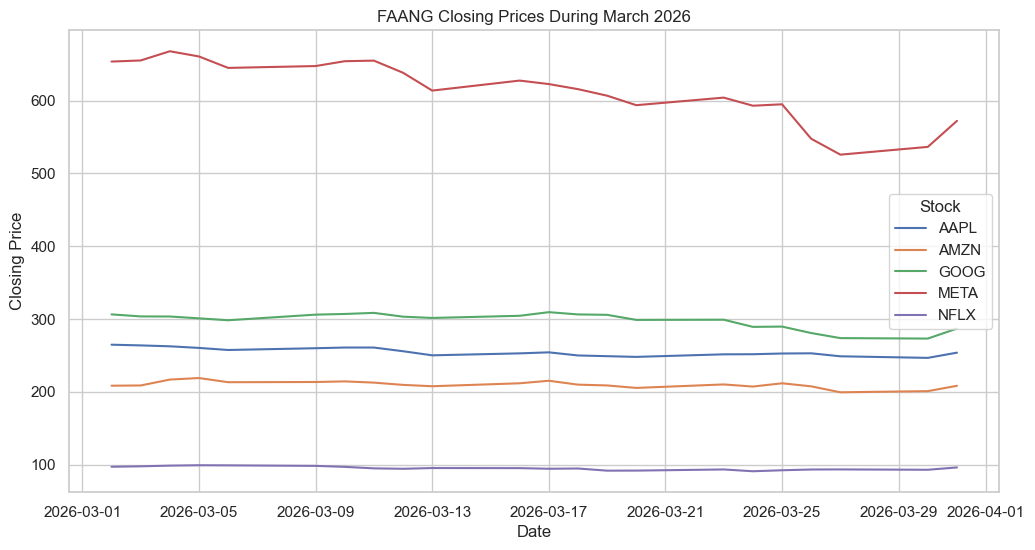

In [68]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="date",
    y="close",
    hue="symbol"
)

plt.title("FAANG Closing Prices During March 2026")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend(title="Stock")

plt.show()


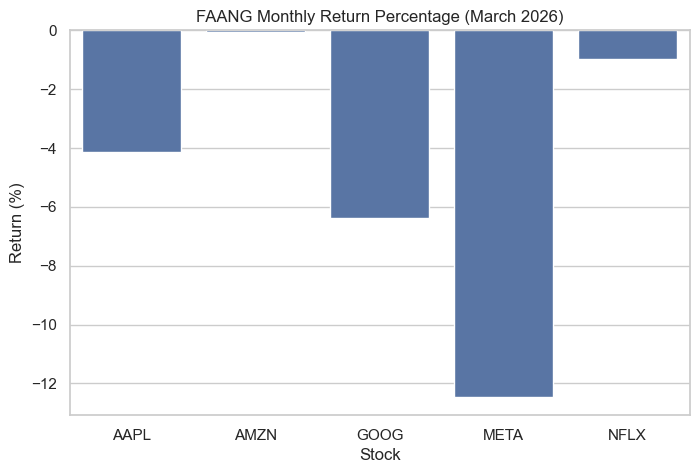

In [70]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=returns_df,
    x="symbol",
    y="monthly_return_pct"
)

plt.title("FAANG Monthly Return Percentage (March 2026)")
plt.xlabel("Stock")
plt.ylabel("Return (%)")

plt.show()


In [72]:
volume_pivot = df.pivot_table(
    index="symbol",
    columns="date",
    values="volume"
)

volume_pivot.head()

date,2026-03-02 00:00:00+00:00,2026-03-03 00:00:00+00:00,2026-03-04 00:00:00+00:00,2026-03-05 00:00:00+00:00,2026-03-06 00:00:00+00:00,2026-03-09 00:00:00+00:00,2026-03-10 00:00:00+00:00,2026-03-11 00:00:00+00:00,2026-03-12 00:00:00+00:00,2026-03-13 00:00:00+00:00,...,2026-03-18 00:00:00+00:00,2026-03-19 00:00:00+00:00,2026-03-20 00:00:00+00:00,2026-03-23 00:00:00+00:00,2026-03-24 00:00:00+00:00,2026-03-25 00:00:00+00:00,2026-03-26 00:00:00+00:00,2026-03-27 00:00:00+00:00,2026-03-30 00:00:00+00:00,2026-03-31 00:00:00+00:00
symbol,,,,,,,,,,,,,,,,,,,,,
AAPL,41576035.0,37994695.0,39258957.0,49424671.0,40628988.0,37958303.0,26403306.0,26131800.0,40132517.0,34193754.0,...,34652568.0,34568663.0,87981315.0,37465587.0,27882961.0,28436700.0,41331888.0,46525772.0,38248670.0,48770963.0
AMZN,43410499.0,42680032.0,54286831.0,60834400.0,50910303.0,53488342.0,35582400.0,34006300.0,44067157.0,34201623.0,...,37711795.0,35932990.0,55381136.0,43926097.0,34266291.0,35103651.0,45915765.0,55772474.0,42710345.0,57843337.0
GOOG,21789144.0,19747708.0,19892189.0,22541297.0,17410318.0,19478510.0,14362200.0,13320300.0,14633273.0,16811259.0,...,13753387.0,15343571.0,34103002.0,22068828.0,27300898.0,21787018.0,28870381.0,25623591.0,21415696.0,30680107.0
META,9801700.0,12240600.0,10709535.0,13249534.0,13000591.0,13463300.0,9844600.0,8940900.0,11019525.0,18758294.0,...,11622275.0,12389745.0,19820750.0,13258580.0,10647042.0,12161179.0,35664700.0,29980300.0,22758800.0,32809500.0
NFLX,79614084.0,58954497.0,52115674.0,53241615.0,39306944.0,47858580.0,40948700.0,33720500.0,33941082.0,29808277.0,...,27264739.0,38239433.0,61493975.0,33605523.0,28812449.0,29491408.0,59159281.0,44308432.0,29207947.0,53674277.0


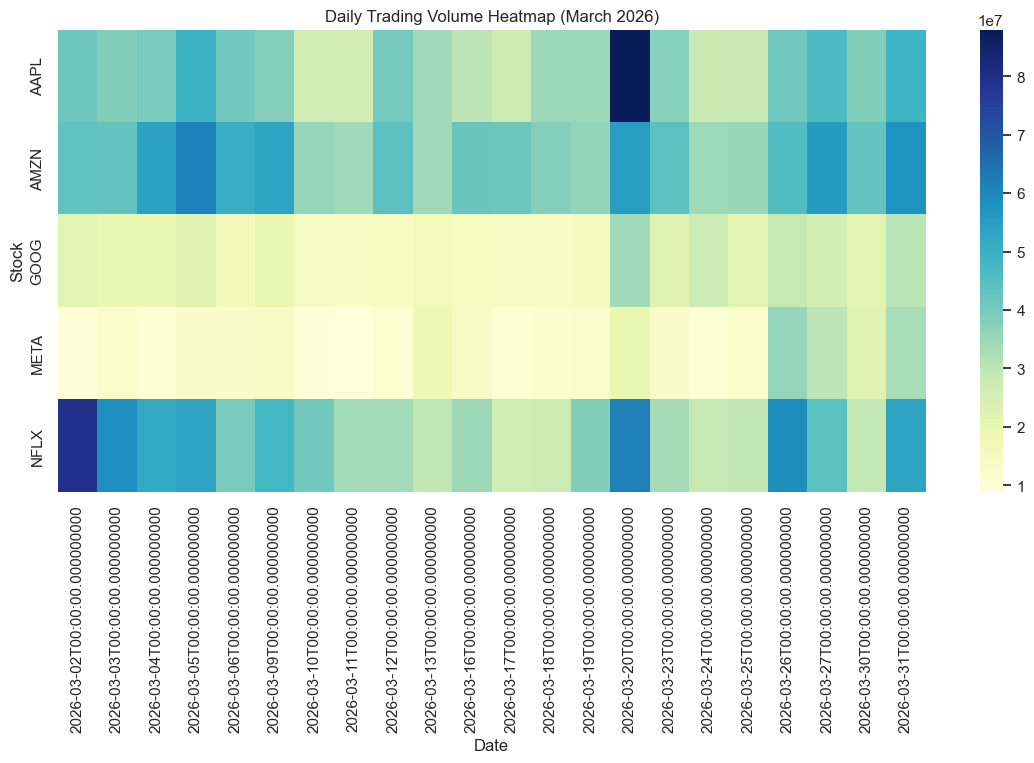

In [74]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    volume_pivot,
    cmap="YlGnBu"
)

plt.title("Daily Trading Volume Heatmap (March 2026)")
plt.xlabel("Date")
plt.ylabel("Stock")

plt.show()

### Visualization Summary

The line chart shows notable differences in price movements among FAANG stocks during March 2026.
The bar chart highlights variation in overall monthly performance, while the heatmap reveals trading
activity patterns across stocks and dates, with some stocks exhibiting consistently higher volumes.

In [77]:
import os

os.makedirs("exports", exist_ok=True)

## Task 4: Exporting and importing data

In [80]:
import json

with open("exports/stockdata.json", "w") as f:
    json.dump(all_data, f, indent=2)

In [82]:
df.to_csv("exports/stockdata.csv", index=False)


In [84]:
with open("exports/stockdata.json", "r") as f:
    json_loaded = json.load(f)

df_json = pd.DataFrame(json_loaded)
df_json.head()

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,549.98,573.69,546.77,572.13,32809500.0,573.6900,546.77,572.13,549.98,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
1,536.38,539.55,528.54,536.38,22758800.0,539.5500,528.54,536.38,536.38,22795203.0,1.0,0.0,META,ARCX,2026-03-30T00:00:00+0000
2,540.10,543.60,520.26,525.72,29980300.0,543.5999,520.26,525.72,540.10,30133010.0,1.0,0.0,META,ARCX,2026-03-27T00:00:00+0000
3,582.49,583.00,543.35,547.54,35664700.0,583.0000,543.35,547.54,582.49,35780131.0,1.0,0.0,META,ARCX,2026-03-26T00:00:00+0000
4,598.74,603.62,593.40,594.89,12161179.0,603.6700,593.40,594.89,598.74,12585031.0,1.0,0.0,META,ARCX,2026-03-25T00:00:00+0000


In [86]:
df_csv = pd.read_csv("exports/stockdata.csv")
df_csv.head()

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,262.440,266.530,260.20,264.72,41576035.0,266.530,260.20,264.72,262.41,41827946.0,1.0,0.0,AAPL,XNAS,2026-03-02 00:00:00+00:00
1,263.480,265.560,260.13,263.75,37994695.0,265.560,260.13,263.75,263.48,38568921.0,1.0,0.0,AAPL,XNAS,2026-03-03 00:00:00+00:00
2,264.650,266.150,261.42,262.52,39258957.0,266.150,261.42,262.52,264.65,39803119.0,1.0,0.0,AAPL,XNAS,2026-03-04 00:00:00+00:00
3,260.745,261.555,257.25,260.29,49424671.0,261.555,257.25,260.29,260.79,49658626.0,1.0,0.0,AAPL,XNAS,2026-03-05 00:00:00+00:00
4,258.740,258.760,254.37,257.46,40628988.0,258.770,254.37,257.46,258.63,41120042.0,1.0,0.0,AAPL,XNAS,2026-03-06 00:00:00+00:00


### Data verification

The first five rows loaded from both the JSON and CSV files match the original
data retrieved from the Marketstack API in Task 2, confirming that the export
and import processes worked correctly.

## Task 5: Querying the Northwind database


In [90]:
import sqlite3
import pandas as pd

In [92]:
# Connect to the database
conn = sqlite3.connect("northwind.db")

# List tables
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

tables

,name
0,Categories
1,sqlite_sequence
2,CustomerCustomerDemo
3,CustomerDemographics
4,Customers
5,Employees
6,EmployeeTerritories
7,Order Details
8,Orders
9,Products


In [94]:
query_products = """
SELECT ProductName, UnitPrice, UnitsInStock
FROM Products
WHERE UnitPrice > 30;
"""

products_df = pd.read_sql(query_products, conn)
products_df

,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26


In [96]:
query_germany = """
SELECT 
    Customers.CompanyName,
    Orders.OrderID,
    Orders.OrderDate,
    Orders.ShipCountry,
    "Order Details".UnitPrice * "Order Details".Quantity AS LineTotal
FROM Orders
JOIN Customers ON Orders.CustomerID = Customers.CustomerID
JOIN "Order Details" ON Orders.OrderID = "Order Details".OrderID
WHERE Orders.ShipCountry = 'Germany';
"""

germany_orders_df = pd.read_sql(query_germany, conn)
germany_orders_df

,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0
...,...,...,...,...,...
80668,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,864.0
80669,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,735.0
80670,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,75.0
80671,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,500.0


In [98]:
conn.close()

## Task 6: Visualizing Northwind data

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

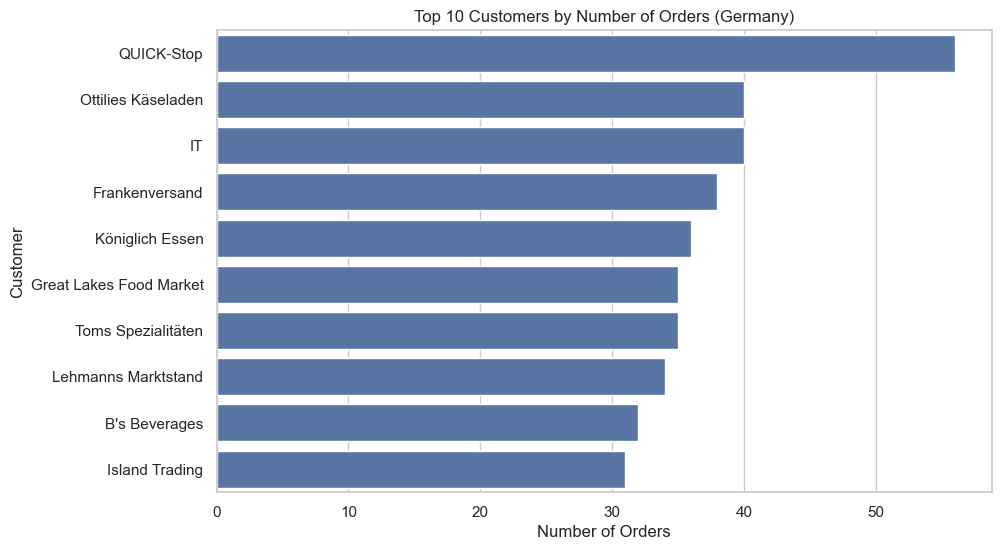

In [103]:
orders_per_customer = (
    germany_orders_df.groupby("CompanyName")["OrderID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=orders_per_customer,
    x="OrderID",
    y="CompanyName"
)

plt.title("Top 10 Customers by Number of Orders (Germany)")
plt.xlabel("Number of Orders")
plt.ylabel("Customer")

plt.show()

In [105]:
daily_sales = (
    germany_orders_df.groupby("OrderDate")["LineTotal"]
    .sum()
    .reset_index()
)

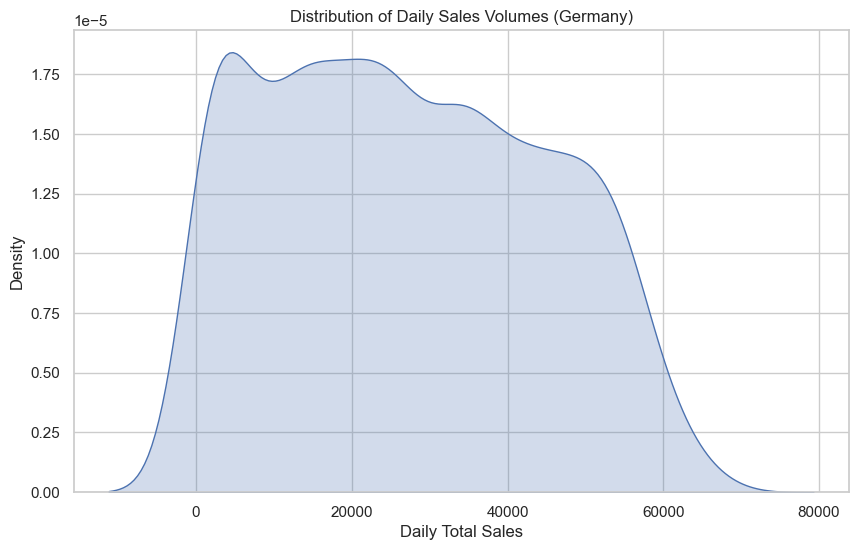

In [107]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=daily_sales,
    x="LineTotal",
    fill=True
)

plt.title("Distribution of Daily Sales Volumes (Germany)")
plt.xlabel("Daily Total Sales")
plt.ylabel("Density")

plt.show()

In [109]:
conn = sqlite3.connect("northwind.db")

query_category_revenue = """
SELECT 
    Categories.CategoryName,
    SUM("Order Details".UnitPrice * "Order Details".Quantity) AS TotalRevenue
FROM "Order Details"
JOIN Products ON "Order Details".ProductID = Products.ProductID
JOIN Categories ON Products.CategoryID = Categories.CategoryID
GROUP BY Categories.CategoryName;
"""

category_revenue_df = pd.read_sql(query_category_revenue, conn)
category_revenue_df

,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Condiments,55802774.45
2,Confections,66347544.94
3,Dairy Products,58034940.00
4,Grains/Cereals,28573512.55
5,Meat/Poultry,64896314.41
6,Produce,32706403.90
7,Seafood,49931965.52


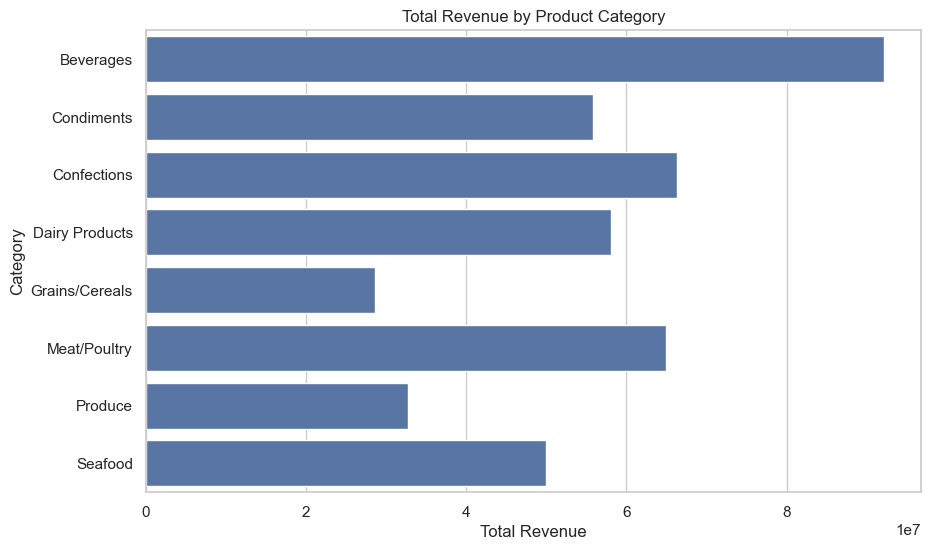

In [111]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_revenue_df,
    x="TotalRevenue",
    y="CategoryName"
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Category")

plt.show()

In [113]:
conn.close()

### Visualization summary

The bar plot highlights the customers with the highest number of orders shipped to Germany.
The KDE plot shows the typical distribution of daily sales volumes, indicating common sales ranges.
Finally, the category revenue bar plot demonstrates which product categories generate the most revenue.

## Task 7: Comparing Python and SQL

In [117]:
import sqlite3
import pandas as pd
import time

In [121]:
conn = sqlite3.connect("northwind.db")

products_df = pd.read_sql("SELECT * FROM Products;", conn)
categories_df = pd.read_sql("SELECT * FROM Categories;", conn)

products_df.head(), categories_df.head()


(   ProductID                   ProductName  SupplierID  CategoryID  \
 0          1                          Chai           1           1   
 1          2                         Chang           1           1   
 2          3                 Aniseed Syrup           1           2   
 3          4  Chef Anton's Cajun Seasoning           2           2   
 4          5        Chef Anton's Gumbo Mix           2           2   
 
        QuantityPerUnit  UnitPrice  UnitsInStock  UnitsOnOrder  ReorderLevel  \
 0   10 boxes x 20 bags      18.00            39             0            10   
 1   24 - 12 oz bottles      19.00            17            40            25   
 2  12 - 550 ml bottles      10.00            13            70            25   
 3       48 - 6 oz jars      22.00            53             0             0   
 4             36 boxes      21.35             0             0             0   
 
   Discontinued  
 0            0  
 1            0  
 2            0  
 3            0  


In [123]:
products_categories_df = products_df.merge(
    categories_df,
    on="CategoryID",
    how="inner"
)

products_categories_df.head()

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [125]:
start_sql = time.time()

query_sql = """
SELECT 
    Categories.CategoryName,
    SUM("Order Details".UnitPrice * "Order Details".Quantity) AS TotalRevenue
FROM "Order Details"
JOIN Products ON "Order Details".ProductID = Products.ProductID
JOIN Categories ON Products.CategoryID = Categories.CategoryID
GROUP BY Categories.CategoryName;
"""

sql_result_df = pd.read_sql(query_sql, conn)

sql_time = time.time() - start_sql

sql_result_df, sql_time

(     CategoryName  TotalRevenue
 0       Beverages   92181842.95
 1      Condiments   55802774.45
 2     Confections   66347544.94
 3  Dairy Products   58034940.00
 4  Grains/Cereals   28573512.55
 5    Meat/Poultry   64896314.41
 6         Produce   32706403.90
 7         Seafood   49931965.52,
 1.2761468887329102)

In [129]:
conn.close()

## Task 8: Wide and long format

In [132]:
import pandas as pd

wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

In [134]:
print("Wide data (before conversion):")
wide_data

Wide data (before conversion):


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


In [136]:
wide_long = pd.melt(
    wide_data,
    id_vars="store",
    var_name="quarter",
    value_name="sales"
)

print("Wide data converted to long format:")
wide_long

Wide data converted to long format:


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


In [138]:
print("Long data (before conversion):")
long_data

Long data (before conversion):


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


In [140]:
long_wide = long_data.pivot(
    index="month",
    columns="product",
    values="units_sold"
).reset_index()

print("Long data converted to wide format:")
long_wide


Long data converted to wide format:


product,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


In [142]:
print("Long-format version before converting back to wide:")
wide_long

Long-format version before converting back to wide:


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


In [144]:
wide_restored = wide_long.pivot(
    index="store",
    columns="quarter",
    values="sales"
).reset_index()

print("Restored wide-format data:")
wide_restored

Restored wide-format data:


quarter,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


In [146]:
print("Wide-format version before converting back to long:")
long_wide

Wide-format version before converting back to long:


product,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


In [148]:
long_restored = pd.melt(
    long_wide,
    id_vars="month",
    var_name="product",
    value_name="units_sold"
)

print("Restored long-format data:")
long_restored

Restored long-format data:


,month,product,units_sold
0,Feb,Laptop,50
1,Jan,Laptop,45
2,Mar,Laptop,55
3,Feb,Phone,110
4,Jan,Phone,120
5,Mar,Phone,130


### Format conversion verification

Both datasets were successfully converted between wide and long formats and then
restored to their original structures. The restored datasets match the originals,
confirming correct use of `melt` and `pivot`.